<a href="https://colab.research.google.com/github/MEpperley/MLP_Implementation_Code/blob/main/MLP_Implementation.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
# ==============================
# Imports
# ==============================
import torch
from torch import nn
from torch.utils.data import DataLoader
from torchvision import datasets, transforms
import matplotlib.pyplot as plt
import numpy as np
from tqdm.notebook import tqdm

print("Libraries imported successfully")

Libraries imported successfully


In [2]:
# ==============================
# Reproducibility and device selection
# ==============================
torch.manual_seed(42)
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

Using device: cpu


In [3]:
# ==============================
# Data Preparation
# ==============================
transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.2860,), (0.3530,))
])

# Load datasets
train_data = datasets.FashionMNIST(root="data", train=True, download=True, transform=transform)
test_data = datasets.FashionMNIST(root="data", train=False, download=True, transform=transform)

# Data loaders
batch_size = 64
train_loader = DataLoader(train_data, batch_size=batch_size, shuffle=True)
test_loader = DataLoader(test_data, batch_size=batch_size, shuffle=False)

print(f"Train samples: {len(train_data)}, Test samples: {len(test_data)}")

100%|██████████| 26.4M/26.4M [00:01<00:00, 13.9MB/s]
100%|██████████| 29.5k/29.5k [00:00<00:00, 202kB/s]
100%|██████████| 4.42M/4.42M [00:01<00:00, 3.36MB/s]
100%|██████████| 5.15k/5.15k [00:00<00:00, 11.0MB/s]

Train samples: 60000, Test samples: 10000


In [4]:
# ==============================
# Model Architecture
# ==============================
class MLP(nn.Module):
    def __init__(self):
        super().__init__()
        self.flatten = nn.Flatten()
        self.hidden1 = nn.Linear(28*28, 256)
        self.relu1 = nn.ReLU()
        self.dropout1 = nn.Dropout(0.5)
        self.hidden2 = nn.Linear(256, 128)
        self.relu2 = nn.ReLU()
        self.dropout2 = nn.Dropout(0.3)
        self.output = nn.Linear(128, 10)

    def forward(self, x):
        x = self.flatten(x)
        x = self.hidden1(x)
        x = self.relu1(x)
        x = self.dropout1(x)
        x = self.hidden2(x)
        x = self.relu2(x)
        x = self.dropout2(x)
        x = self.output(x)
        return x

# Instantiate model
model = MLP().to(device)
print(model)

MLP(
  (flatten): Flatten(start_dim=1, end_dim=-1)
  (hidden1): Linear(in_features=784, out_features=256, bias=True)
  (relu1): ReLU()
  (dropout1): Dropout(p=0.5, inplace=False)
  (hidden2): Linear(in_features=256, out_features=128, bias=True)
  (relu2): ReLU()
  (dropout2): Dropout(p=0.3, inplace=False)
  (output): Linear(in_features=128, out_features=10, bias=True)
)


In [5]:
# ==============================
# Training Setup
# ==============================
loss_fn = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(model.parameters(), lr=0.001)

epochs = 10
train_losses = []
train_accuracies = []
test_accuracies = []

In [6]:
# ==============================
# Training and Evaluation Loop
# ==============================
for epoch in range(epochs):
    model.train()
    total_loss = 0.0
    correct_train = 0
    total_train = 0

    for X, y in tqdm(train_loader, desc=f"Epoch {epoch+1}/{epochs}", unit="batch"):
        X, y = X.to(device), y.to(device)
        optimizer.zero_grad()
        outputs = model(X)
        loss = loss_fn(outputs, y)
        loss.backward()
        optimizer.step()

        total_loss += loss.item() * X.size(0)
        _, preds = torch.max(outputs, 1)
        correct_train += (preds == y).sum().item()
        total_train += y.size(0)

    avg_loss = total_loss / total_train
    train_accuracy = correct_train / total_train

    # Evaluation
    model.eval()
    correct_test = 0
    total_test = 0
    with torch.no_grad():
        for X, y in test_loader:
            X, y = X.to(device), y.to(device)
            outputs = model(X)
            _, preds = torch.max(outputs, 1)
            correct_test += (preds == y).sum().item()
            total_test += y.size(0)

    test_accuracy = correct_test / total_test

    train_losses.append(avg_loss)
    train_accuracies.append(train_accuracy)
    test_accuracies.append(test_accuracy)

    print(f"Epoch {epoch+1}/{epochs} - Loss: {avg_loss:.4f} - Train Acc: {train_accuracy:.4f} - Test Acc: {test_accuracy:.4f}")

Epoch 1/10:   0%|          | 0/938 [00:00<?, ?batch/s]

Epoch 1/10 - Loss: 0.5860 - Train Acc: 0.7887 - Test Acc: 0.8381


Epoch 2/10:   0%|          | 0/938 [00:00<?, ?batch/s]

Epoch 2/10 - Loss: 0.4526 - Train Acc: 0.8372 - Test Acc: 0.8533


Epoch 3/10:   0%|          | 0/938 [00:00<?, ?batch/s]

...

Epoch 8/10 - Loss: 0.3621 - Train Acc: 0.8680 - Test Acc: 0.8730


Epoch 9/10:   0%|          | 0/938 [00:00<?, ?batch/s]

Epoch 9/10 - Loss: 0.3544 - Train Acc: 0.8715 - Test Acc: 0.8671


Epoch 10/10:   0%|          | 0/938 [00:00<?, ?batch/s]

Epoch 10/10 - Loss: 0.3496 - Train Acc: 0.8731 - Test Acc: 0.8762


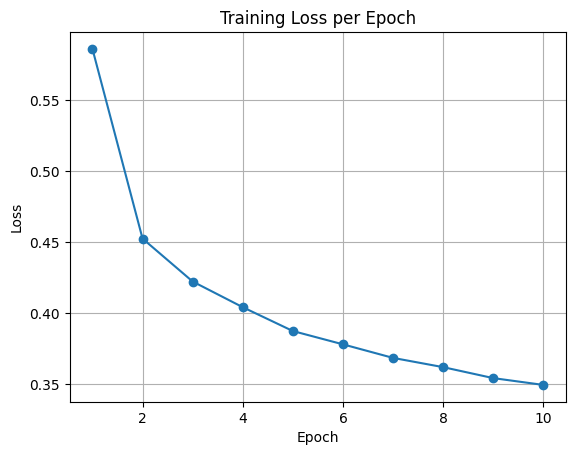

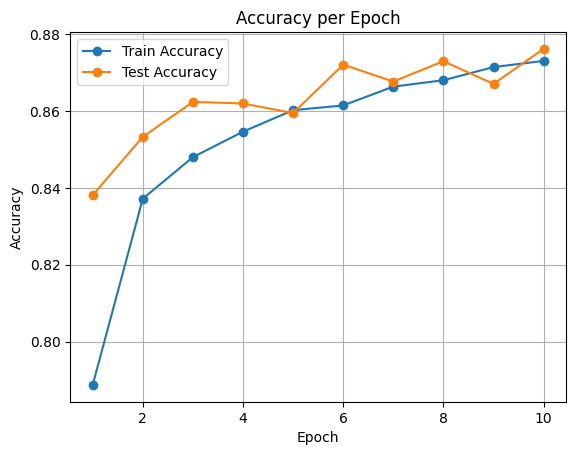

In [7]:
# ==============================
# Visualization
# ==============================
epochs_range = range(1, epochs + 1)

plt.figure()
plt.plot(epochs_range, train_losses, marker='o') # Training loss curve
plt.title("Training Loss per Epoch")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.grid()
plt.show()

plt.figure()
plt.plot(epochs_range, train_accuracies, marker='o', label="Train Accuracy")
plt.plot(epochs_range, test_accuracies, marker='o', label="Test Accuracy")
plt.title("Accuracy per Epoch")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.legend()
plt.grid()
plt.show()

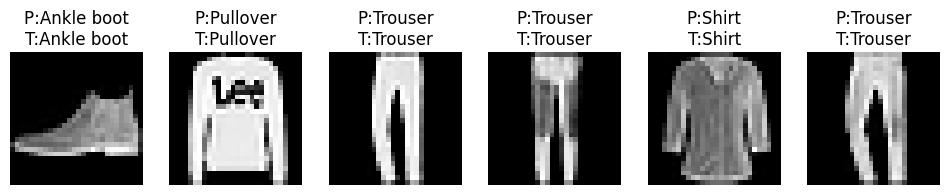

In [8]:
# ==============================
# Display a few test images with predictions
# ==============================
classes = train_data.classes # Class labels for Fashion-MNIST
model.eval() # Evaluation mode
examples = 6 # Number of sample images to display
fig, axes = plt.subplots(1, examples, figsize=(12, 3)) # Create subplot grid
with torch.no_grad(): # No gradient computation
    it = iter(test_loader) # Create iterator
    X_batch, y_batch = next(it) # Get one batch
    X_batch = X_batch.to(device) # Move to device
    outputs = model(X_batch) # Model predictions
    _, preds = torch.max(outputs, 1) # Predicted labels

    for i in range(examples): # Loop over images
        img = X_batch[i].cpu().squeeze(0) # Convert tensor to image format
        axes[i].imshow(img, cmap='gray') # Display image
        axes[i].set_title(f"P:{classes[preds[i]]}\nT:{classes[y_batch[i]]}")
        axes[i].axis('off') # Hide axes
plt.show()

In [ ]:
# ==============================
# Save Model
# ==============================
torch.save(model.state_dict(), "mlp_fashion_mnist.pth") # Save trained model weights
print("Model saved to mlp_fashion_mnist.pth") # Confirmation message

Model saved to mlp_fashion_mnist.pth
